In [1]:
# Import libraries
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
# File paths
digitized_path = '/data/personal_data/project_water_bodies_detection/Iran/labeled_data/Iran_labeled_data_clipped.tif' # Manual digitized map
cems_path = '/data/personal_data/project_water_bodies_detection/Iran/labeled_data/ground_truth_EMSR_352.tif' # CEMS map
save_path = './comparison_ground_truth.png' # Save path

# Parameters for plot
TITLE_SIZE = 25      # Subplot title size
SUP_AXIS_SIZE = 25   # Sup axis size
TICK_LABEL_SIZE = 20 # Tick label size
LEGEND_SIZE = 25     # Legend font size

In [5]:
def plot_comparison_ground_truth(path1, path2, save_path=None):
    # Open raster files
    with rasterio.open(path1) as src1, rasterio.open(path2) as src2:
        img1 = src1.read(1) # Digitized map
        img2 = src2.read(1) # CEMS map
        transform = src1.transform
        
        # Check if the shapes of the two images are the same
        if img1.shape != img2.shape:
            print("Shape mismatch!")
            return

        # Convert to binary images
        bin1 = (img1 > 0).astype(int)
        bin2 = (img2 > 0).astype(int)

        # Calculate IoU
        intersection = np.logical_and(bin1, bin2)
        union = np.logical_or(bin1, bin2)
        iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0
        print(f"--- IoU: {iou_score:.4f} ---")

        # Calculate difference map
        diff_map = bin1 - bin2
        
        # Plot
        fig, axs = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

        # 1) Digitized map
        show((src1, 1), ax=axs[0], cmap='Blues')
        axs[0].set_title('Manual Digitized Map', fontsize=TITLE_SIZE, fontweight='bold', pad=20)
        
        # 2) CEMS map
        show((src2, 1), ax=axs[1], cmap='Greens')
        axs[1].set_title('CEMS MAP', fontsize=TITLE_SIZE, fontweight='bold', pad=20)

        # 3) Difference map
        cmap_diff = ListedColormap(['red', 'white', 'blue'])
        show(diff_map, transform=transform, ax=axs[2], cmap=cmap_diff)
        axs[2].set_title('Difference Map (IoU: {:.3f})'.format(iou_score), fontsize=TITLE_SIZE, fontweight='bold', pad=20)

        # Common style applied (axes, grid, labels)
        for ax in axs:
            # Grid
            ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
            
            # Tick label size
            ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE)
            
        # Adjust position with x and y value
        fig.supxlabel('Longitude', fontsize=SUP_AXIS_SIZE, y=0.02) 
        fig.supylabel('Latitude', fontsize=SUP_AXIS_SIZE, x=-0.01)

        # Legend (In difference map)
        legend_elements = [
            Patch(facecolor='blue', edgecolor='gray', label='Digitized Map only'),
            Patch(facecolor='red', edgecolor='gray', label='CEMS Map only')
        ]
        axs[2].legend(handles=legend_elements, loc='upper left', 
                      fontsize=LEGEND_SIZE, framealpha=0.9)

        # Save and plot
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

--- IoU: 0.8045 ---


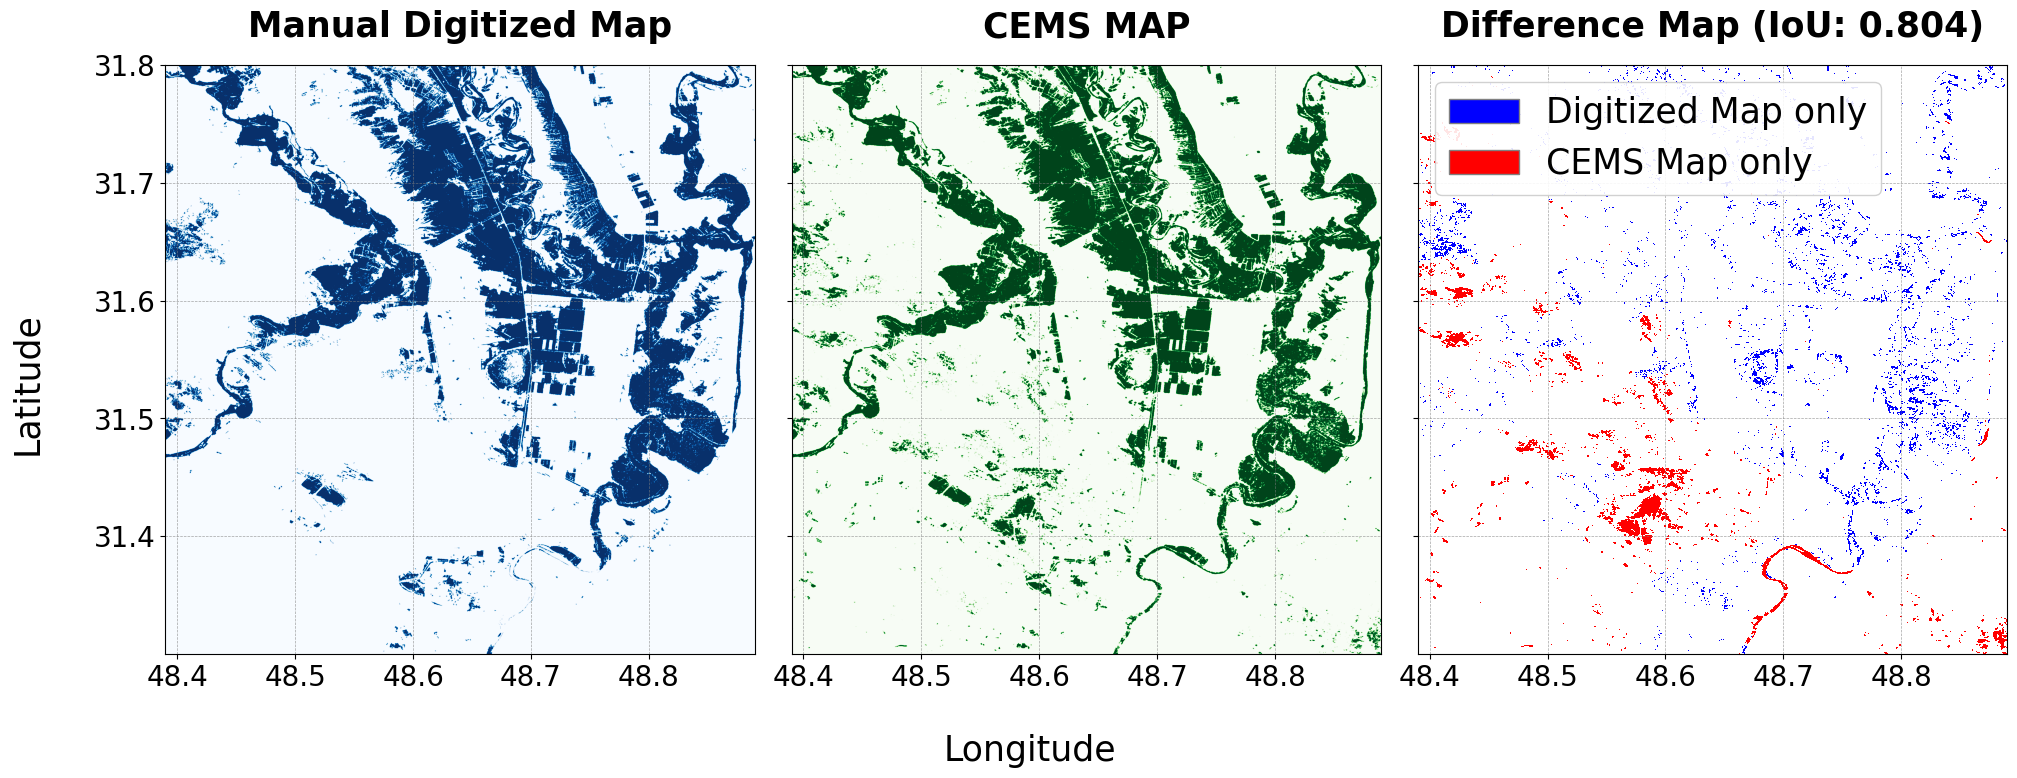

In [6]:
plot_comparison_ground_truth(cems_path, digitized_path, save_path)